In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
        print(os.path.join(dirname))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input
/kaggle/input/datasets
/kaggle/input/datasets/aalihhiader
/kaggle/input/datasets/aalihhiader/military-camouflage-soldiers-dataset-mcs1k
/kaggle/input/datasets/aalihhiader/military-camouflage-soldiers-dataset-mcs1k/dataset-splitM
/kaggle/input/datasets/aalihhiader/military-camouflage-soldiers-dataset-mcs1k/dataset-splitM/Training
/kaggle/input/datasets/aalihhiader/military-camouflage-soldiers-dataset-mcs1k/dataset-splitM/Training/GT
/kaggle/input/datasets/aalihhiader/military-camouflage-soldiers-dataset-mcs1k/dataset-splitM/Training/images
/kaggle/input/datasets/aalihhiader/military-camouflage-soldiers-dataset-mcs1k/dataset-splitM/Testing
/kaggle/input/datasets/aalihhiader/military-camouflage-soldiers-dataset-mcs1k/dataset-splitM/Testing/GT
/kaggle/input/datasets/aalihhiader/military-camouflage-soldiers-dataset-mcs1k/dataset-splitM/Testing/images


In [2]:
import numpy as np
import os
from PIL import Image
import matplotlib.pyplot as plt

import torch
import torchvision
from torchvision import transforms as T
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection.mask_rcnn import MaskRCNNPredictor

In [3]:
IMAGES_DIR = "/kaggle/input/datasets/aalihhiader/military-camouflage-soldiers-dataset-mcs1k/dataset-splitM/Training/images/"
MASKS_DIR = "/kaggle/input/datasets/aalihhiader/military-camouflage-soldiers-dataset-mcs1k/dataset-splitM/Training/GT/"

In [4]:
images = sorted(os.listdir(IMAGES_DIR))
masks = sorted(os.listdir(MASKS_DIR))

In [5]:
idx = 0
img = Image.open(IMAGES_DIR + images[idx]).convert("RGB")
mask = Image.open(MASKS_DIR + masks[idx])

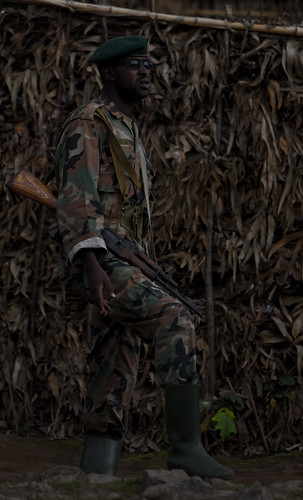

In [6]:
img

In [7]:
np.unique(mask)

array([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,
        13,  14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,
        26,  27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,
        39,  40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,
        52,  53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,
        65,  66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,
        78,  79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,
        91,  92,  93,  94,  95,  97,  98,  99, 100, 101, 102, 103, 104,
       105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117,
       118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130,
       131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143,
       144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156,
       157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169,
       170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 18

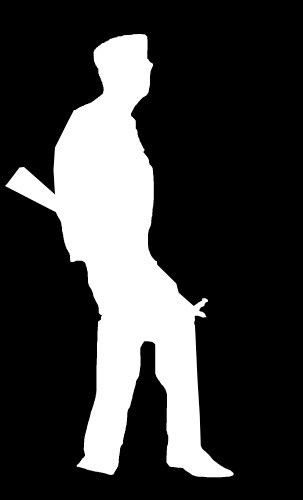

In [8]:
mask

In [9]:
class CustDat(torch.utils.data.Dataset):

    def __init__(self, images, masks):
        self.imgs = images
        self.masks = masks

    def __getitem__(self, idx):

        # load image
        img_path = os.path.join(IMAGES_DIR, self.imgs[idx])
        img = Image.open(img_path).convert("RGB")

        # load mask
        mask_path = os.path.join(MASKS_DIR, self.masks[idx])
        mask = np.array(Image.open(mask_path))

        # ensure single channel
        if mask.ndim == 3:
            mask = mask[:, :, 0]

        # binary mask
        mask = (mask > 0).astype(np.uint8)

        # find object pixels
        pos = np.where(mask)

        # bounding box
        xmin = np.min(pos[1])
        xmax = np.max(pos[1])
        ymin = np.min(pos[0])
        ymax = np.max(pos[0])

        boxes = torch.as_tensor([[xmin, ymin, xmax, ymax]], dtype=torch.float32)

        labels = torch.ones((1,), dtype=torch.int64)

        masks = torch.as_tensor(mask[None, :, :], dtype=torch.uint8)

        target = {
            "boxes": boxes,
            "labels": labels,
            "masks": masks
        }

        return T.ToTensor()(img), target

    def __len__(self):
        return len(self.imgs)

In [10]:
dataset = CustDat(images, masks)
img, target = dataset[0]

print(img.shape)
print(target["masks"].shape)
print(target["boxes"])

print(type(img))
print(type(target))
print(target.keys())

torch.Size([3, 500, 303])
torch.Size([1, 500, 303])
tensor([[  0.,  32., 239., 479.]])
<class 'torch.Tensor'>
<class 'dict'>
dict_keys(['boxes', 'labels', 'masks'])


In [11]:
np.random.seed(42)

indices = np.arange(len(images))
np.random.shuffle(indices)

split = int(0.9 * len(indices))

train_indices = indices[:split]
val_indices = indices[split:]

train_imgs = np.array(images)[train_indices]
train_masks = np.array(masks)[train_indices]

val_imgs = np.array(images)[val_indices]
val_masks = np.array(masks)[val_indices]

In [12]:
print("Total images:", len(images))
print("Training images:", len(train_imgs))
print("Validation images:", len(val_imgs))

Total images: 748
Training images: 673
Validation images: 75


In [13]:
train_dataset = CustDat(train_imgs, train_masks)
val_dataset = CustDat(val_imgs, val_masks)

In [14]:
img, target = train_dataset[100]

print(img.shape)
print(target["boxes"])
print(target["masks"].shape)

torch.Size([3, 720, 1280])
tensor([[600., 288., 679., 391.]])
torch.Size([1, 720, 1280])


In [15]:
def custom_collate(batch):
    images = []
    targets = []

    for img, target in batch:
        images.append(img)
        targets.append(target)

    return images, targets

In [16]:
train_dl = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=2,
    shuffle=True,
    collate_fn=custom_collate,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

val_dl = torch.utils.data.DataLoader(
    val_dataset,
    batch_size=2,
    shuffle=False,
    collate_fn=custom_collate,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

In [17]:
imgs, targets = next(iter(train_dl))

print(type(imgs))
print(type(imgs[0]))

print(type(targets))
print(type(targets[0]))

print(targets[0].keys())

<class 'list'>
<class 'torch.Tensor'>
<class 'list'>
<class 'dict'>
dict_keys(['boxes', 'labels', 'masks'])


In [18]:
model = torchvision.models.detection.maskrcnn_resnet50_fpn(weights="DEFAULT")

num_classes = 2  # background + camouflaged object

# replace box predictor
in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

# replace mask predictor
in_features_mask = model.roi_heads.mask_predictor.conv5_mask.in_channels
hidden_layer = 256
model.roi_heads.mask_predictor = MaskRCNNPredictor(in_features_mask, hidden_layer, num_classes)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

Downloading: "https://download.pytorch.org/models/maskrcnn_resnet50_fpn_coco-bf2d0c1e.pth" to /root/.cache/torch/hub/checkpoints/maskrcnn_resnet50_fpn_coco-bf2d0c1e.pth


100%|██████████| 170M/170M [00:01<00:00, 174MB/s]  


MaskRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=0.0)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=0.0)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=0.0)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): FrozenBatchNorm2d(256, eps=0.0)
          (relu): ReLU(in

In [19]:
params = [p for p in model.parameters() if p.requires_grad]

optimizer = torch.optim.SGD(
    params,
    lr=0.005,
    momentum=0.9,
    weight_decay=0.0005
)

In [20]:
from tqdm import tqdm

num_epochs = 30

all_train_losses = []
all_val_losses = []

for epoch in range(num_epochs):

    model.train()
    train_loss = 0

    progress = tqdm(train_dl, desc=f"Epoch {epoch+1}/{num_epochs}")

    for imgs, targets in progress:

        imgs = [img.to(device) for img in imgs]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        loss_dict = model(imgs, targets)
        losses = sum(loss for loss in loss_dict.values())

        optimizer.zero_grad()
        losses.backward()
        optimizer.step()

        train_loss += losses.item()

        progress.set_postfix(loss=losses.item())

    train_loss /= len(train_dl)
    all_train_losses.append(train_loss)

    # validation
    model.eval()
    val_loss = 0
    
    model.train() 

    with torch.no_grad():

        for imgs, targets in val_dl:

            imgs = [img.to(device) for img in imgs]
            targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

            loss_dict = model(imgs, targets)
            losses = sum(loss for loss in loss_dict.values())

            val_loss += losses.item()

    val_loss /= len(val_dl)
    all_val_losses.append(val_loss)

    print(f"Epoch {epoch+1} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

Epoch 1/30: 100%|██████████| 337/337 [03:37<00:00,  1.55it/s, loss=0.8]  


Epoch 1 | Train Loss: 0.9033 | Val Loss: 0.8208


Epoch 2/30: 100%|██████████| 337/337 [03:37<00:00,  1.55it/s, loss=0.616]


Epoch 2 | Train Loss: 0.7446 | Val Loss: 0.6640


Epoch 3/30: 100%|██████████| 337/337 [03:37<00:00,  1.55it/s, loss=0.439]


...

Epoch 28 | Train Loss: 0.3090 | Val Loss: 0.5935


Epoch 29/30: 100%|██████████| 337/337 [03:40<00:00,  1.53it/s, loss=0.16] 


Epoch 29 | Train Loss: 0.2684 | Val Loss: 0.5157


Epoch 30/30: 100%|██████████| 337/337 [03:42<00:00,  1.52it/s, loss=0.118] 


Epoch 30 | Train Loss: 0.1933 | Val Loss: 0.5138


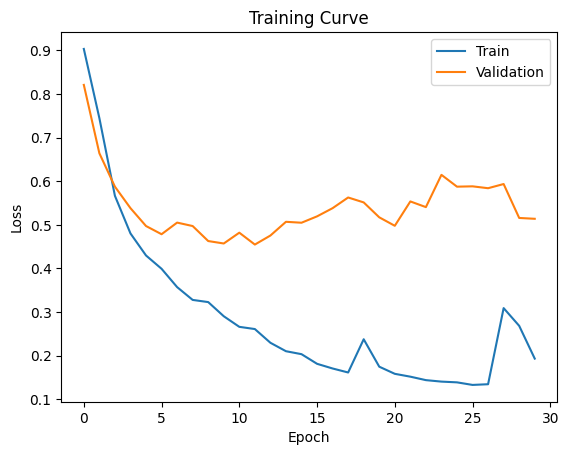

In [21]:
plt.plot(all_train_losses, label="Train")
plt.plot(all_val_losses, label="Validation")
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Curve")
plt.show()

In [22]:
torch.save(model.state_dict(), "maskrcnn_acd1k_weights.pth")

In [23]:
torch.save({
    "epoch": epoch,
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    "train_losses": all_train_losses,
    "val_losses": all_val_losses
}, "maskrcnn_acd1k_checkpoint.pth")

In [24]:
model = torchvision.models.detection.maskrcnn_resnet50_fpn(weights=None)

num_classes = 2

in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

in_features_mask = model.roi_heads.mask_predictor.conv5_mask.in_channels
model.roi_heads.mask_predictor = MaskRCNNPredictor(in_features_mask, 256, num_classes)

model.load_state_dict(torch.load("maskrcnn_acd1k_weights.pth"))
model.eval()

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 171MB/s] 


MaskRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=1e-05)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=1e-05)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=1e-05)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): FrozenBatchNorm2d(256, eps=1e-05)
          (relu):

Camouflaged Military Soldier Density Estimation

In [25]:
import gradio as gr
import torch
import torchvision
from torchvision import transforms as T
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection.mask_rcnn import MaskRCNNPredictor
from PIL import Image, ImageDraw, ImageFont
import numpy as np
import cv2
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import io
import os
import datetime
import tempfile


# ─────────────────────────────────────────────────────────────────────────────
# 1.  MODEL SETUP
# ─────────────────────────────────────────────────────────────────────────────

WEIGHTS_PATH    = "maskrcnn_acd1k_weights.pth"   # ← update path if needed
SCORE_THRESHOLD = 0.5
MASK_THRESHOLD  = 0.5
NUM_CLASSES     = 2                               # background + camouflaged soldier
DEVICE          = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Per-instance colour palette (RGB)
PALETTE = [
    (255,  60,  60),
    ( 60, 200,  60),
    ( 60, 120, 255),
    (255, 200,   0),
    (255,  80, 200),
    (  0, 220, 220),
    (255, 140,   0),
    (160,  60, 255),
]


def build_model(weights_path: str, device: torch.device):
    """Rebuild architecture and load saved weights."""
    mdl = torchvision.models.detection.maskrcnn_resnet50_fpn(weights=None)
    in_feat = mdl.roi_heads.box_predictor.cls_score.in_features
    mdl.roi_heads.box_predictor = FastRCNNPredictor(in_feat, NUM_CLASSES)
    in_feat_mask = mdl.roi_heads.mask_predictor.conv5_mask.in_channels
    mdl.roi_heads.mask_predictor = MaskRCNNPredictor(in_feat_mask, 256, NUM_CLASSES)
    mdl.load_state_dict(torch.load(weights_path, map_location=device))
    mdl.to(device)
    mdl.eval()
    return mdl


model = build_model(WEIGHTS_PATH, DEVICE)


# ─────────────────────────────────────────────────────────────────────────────
# 2.  INFERENCE
# ─────────────────────────────────────────────────────────────────────────────

def run_inference(pil_image: Image.Image, threshold: float):
    tensor = T.ToTensor()(pil_image.convert("RGB")).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        pred = model(tensor)[0]

    scores = pred["scores"].cpu().numpy()
    keep   = scores >= threshold
    boxes  = pred["boxes"].cpu().numpy()[keep]
    masks  = (pred["masks"].cpu().numpy()[keep, 0] >= MASK_THRESHOLD).astype(np.uint8)
    scores = scores[keep]
    return boxes, masks, scores


# ─────────────────────────────────────────────────────────────────────────────
# 3.  VISUALISATION HELPERS
# ─────────────────────────────────────────────────────────────────────────────

# ── 3a. Annotated image (masks + boxes + labels) ──────────────────────────────
def annotate_image(pil_image, boxes, masks, scores):
    img_np  = np.array(pil_image.convert("RGB"), dtype=np.uint8).copy()
    overlay = img_np.copy()

    for i, (box, mask, score) in enumerate(zip(boxes, masks, scores)):
        col = PALETTE[i % len(PALETTE)]
        coloured = np.zeros_like(img_np)
        for c, v in enumerate(col):
            coloured[:, :, c] = v
        mb = mask.astype(bool)
        overlay[mb] = (0.45 * overlay[mb] + 0.55 * coloured[mb]).astype(np.uint8)
        x1, y1, x2, y2 = map(int, box)
        cv2.rectangle(overlay, (x1, y1), (x2, y2), col, 2)
        label = f"#{i+1} {score:.2f}"
        (tw, th), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.55, 1)
        cv2.rectangle(overlay, (x1, y1 - th - 8), (x1 + tw + 4, y1), col, -1)
        cv2.putText(overlay, label, (x1 + 2, y1 - 4),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.55, (255, 255, 255), 1, cv2.LINE_AA)
    return Image.fromarray(overlay)


# ── 3b. Side-by-side original vs annotated ────────────────────────────────────
def side_by_side(pil_original, pil_annotated):
    W, H     = pil_original.size
    canvas   = Image.new("RGB", (W * 2 + 10, H + 30), (30, 30, 30))
    draw     = ImageDraw.Draw(canvas)
    canvas.paste(pil_original,  (0,     30))
    canvas.paste(pil_annotated, (W + 10, 30))
    draw.text((W // 2 - 30, 6),  "Original",  fill=(200, 200, 200))
    draw.text((W + 10 + W // 2 - 40, 6), "Detections", fill=(200, 200, 200))
    return canvas


# ── 3c. Confidence bar chart ──────────────────────────────────────────────────
def confidence_bar_chart(scores):
    n = len(scores)
    fig, ax = plt.subplots(figsize=(max(4, n * 0.55 + 1), 3.5), dpi=100)
    bar_colors = [
        "#{:02x}{:02x}{:02x}".format(*PALETTE[i % len(PALETTE)]) for i in range(n)
    ]
    bars = ax.bar([f"#{i+1}" for i in range(n)], scores, color=bar_colors,
                  edgecolor="white", linewidth=0.8)
    ax.set_ylim(0, 1.05)
    ax.set_xlabel("Detection ID", fontsize=10)
    ax.set_ylabel("Confidence Score", fontsize=10)
    ax.set_title("Per-Detection Confidence Scores", fontsize=11, fontweight="bold")
    ax.axhline(0.5, color="gray", linestyle="--", linewidth=0.8, label="threshold=0.50")
    ax.legend(fontsize=8)
    for bar, s in zip(bars, scores):
        ax.text(bar.get_x() + bar.get_width() / 2, s + 0.02,
                f"{s:.2f}", ha="center", va="bottom", fontsize=8, color="white")
    ax.set_facecolor("#1a1a2e")
    fig.patch.set_facecolor("#16213e")
    ax.tick_params(colors="white")
    ax.xaxis.label.set_color("white")
    ax.yaxis.label.set_color("white")
    ax.title.set_color("white")
    ax.spines[:].set_color("#444")
    plt.tight_layout()
    buf = io.BytesIO()
    plt.savefig(buf, format="png", bbox_inches="tight")
    plt.close(fig)
    buf.seek(0)
    return Image.open(buf).copy()


# ── 3d. Density heatmap ───────────────────────────────────────────────────────
def density_heatmap(masks, image_size):
    H, W = image_size
    density = np.zeros((H, W), dtype=np.float32)
    for mask in masks:
        if mask.shape == (H, W):
            density += mask.astype(np.float32)
    fig, ax = plt.subplots(figsize=(6, 4), dpi=100)
    im = ax.imshow(density, cmap="hot", interpolation="nearest")
    plt.colorbar(im, ax=ax, label="Soldiers / pixel")
    ax.set_title("Soldier Density Heatmap", fontsize=11, fontweight="bold")
    ax.axis("off")
    plt.tight_layout()
    buf = io.BytesIO()
    plt.savefig(buf, format="png", bbox_inches="tight")
    plt.close(fig)
    buf.seek(0)
    return Image.open(buf).copy()


# ── 3f. Mask coverage % ───────────────────────────────────────────────────────
def mask_coverage(masks, image_size):
    H, W = image_size
    total_px = H * W
    if len(masks) == 0:
        return 0.0, 0
    union = np.zeros((H, W), dtype=bool)
    for mask in masks:
        if mask.shape == (H, W):
            union |= mask.astype(bool)
    covered = int(union.sum())
    return round(covered / total_px * 100, 2), covered


# ─────────────────────────────────────────────────────────────────────────────
# 6.  MAIN PREDICT FUNCTION
# ─────────────────────────────────────────────────────────────────────────────


def predict(pil_image: Image.Image, score_threshold: float):

    if pil_image is None:
        return ("No image provided.", None, None, None)

    try:
        boxes, masks, scores = run_inference(pil_image, score_threshold)
    except Exception as exc:
        return (f"Inference error: {exc}", None, None, None)

    n  = len(scores)
    W, H = pil_image.size

    # ── summary ───────────────────────────────────────────────────────────────
    coverage_pct, covered_px = mask_coverage(masks, (H, W))

    if n == 0:
        summary = (
            "No camouflaged soldiers detected above the confidence threshold.\n"
            f"Image size : {W}×{H} px"
        )
    else:
        lines = [
            f"Soldiers Detected  : {n}",
            f"Confidence Range   : {scores.min():.3f} – {scores.max():.3f}",
            f"Mean Confidence    : {scores.mean():.3f}",
            f"Mask Coverage      : {coverage_pct}%  ({covered_px:,} px / {W*H:,} px)",
            f"Image Size         : {W}×{H} px",
            "",
        ]
        for i, (score, box) in enumerate(zip(scores, boxes)):
            x1, y1, x2, y2 = map(int, box)
            lines.append(
                f"  #{i+1:>2}  score={score:.3f}  "
                f"bbox=[{x1},{y1},{x2},{y2}]  size={(x2-x1)}×{(y2-y1)}px"
            )
        summary = "\n".join(lines)

    # ── visuals ───────────────────────────────────────────────────────────────
    annotated  = annotate_image(pil_image, boxes, masks, scores) if n > 0 else pil_image.copy()
    sbs        = side_by_side(pil_image, annotated)
    bar_chart  = confidence_bar_chart(scores) if n > 0 else None
    heatmap    = density_heatmap(masks, (H, W))            if n > 0 else None



    return (
    summary,
    sbs,
    bar_chart,
    heatmap,
)



# ─────────────────────────────────────────────────────────────────────────────
# 7.  GRADIO UI
# ─────────────────────────────────────────────────────────────────────────────

CSS = """
body {
    background: #0f172a;
}

.gradio-container {
    max-width: 1400px !important;
    margin: auto;
}

/* Cards */
.gr-group,
.gr-box,
.gr-panel {
    background-color: #1e293b !important;
    border: 1px solid #334155 !important;
    border-radius: 12px !important;
}

/* Text */
h1, h2, h3, p, label {
    color: white !important;
}

/* Textbox */
textarea {
    background-color: #111827 !important;
    color: white !important;
}

/* Button */
.gr-button-primary {
    background: #2563eb !important;
    color: white !important;
    border-radius: 8px !important;
}

footer {
    display: none !important;
}
"""

with gr.Blocks(title="Military Camouflage Soldier Density Estimation", css=CSS) as demo:

    gr.HTML("""
<div style="
padding:20px;
background:#1e293b;
border-radius:12px;
margin-bottom:15px;
text-align:center;
">
<h1>Military Camouflage Detection & Density Analysis System</h1>
<h3>Deep Learning Based Instance Segmentation using Mask R-CNN (ResNet-50 FPN)</h3>
<p>Detect, localize, and analyze camouflaged military personnel in complex environments.</p>
</div>
""")

    # ── INPUT ROW ────────────────────────────────────────────────────────────
    with gr.Row():
        with gr.Column(scale=1, min_width=260):
            input_image = gr.Image(type="pil", label="Upload Image")
            threshold_slider = gr.Slider(
                minimum=0.10, maximum=0.99, value=0.50, step=0.01,
                label="Confidence Threshold",
            )
            with gr.Row():
                run_btn    = gr.Button("▶  Run Estimation", variant="primary")

        with gr.Column(scale=3):
            summary_box = gr.Textbox(label="📊 Detection Summary", lines=10)

    # ── MAIN VISUALS ROW ─────────────────────────────────────────────────────
    # ── RESULTS TABS ────────────────────────────────────────────────────────
    with gr.Tabs():

        with gr.Tab("Detection Results"):
            sbs_out = gr.Image(
                type="pil",
                label="Original vs Detection",
                height=600
            )

        with gr.Tab("Confidence Analysis"):
            chart_out = gr.Image(
                type="pil",
                label="Confidence Scores",
                height=500
            )

        with gr.Tab("Density Analysis"):
            heatmap_out = gr.Image(
                type="pil",
                label="Density Heatmap",
                height=500
            )


    # ── WIRING ────────────────────────────────────────────────────────────────
    run_btn.click(
        fn=predict,
        inputs=[input_image, threshold_slider],
        outputs=[
    summary_box,
    sbs_out,
    chart_out,
    heatmap_out,
],
    )


if __name__ == "__main__":
    demo.launch(share=True)   # generates a public gradio.live link for Kaggle

/tmp/ipykernel_58/3216687480.py:287: DeprecationWarning: The 'css' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'css' to Blocks.launch() instead.
  with gr.Blocks(title="Military Camouflage Soldier Density Estimation", css=CSS) as demo:


* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://b7b12b91a8d5fae25c.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
